# Sellside Hawk/Dove Label Predictiveness — Global Front-End STIR Futures Around Central Bank Speeches

Six legs, each trading its own front-end STIR future:

| leg | instrument | source |
|---|---|---|
| FED | SR3 — 3M SOFR (CME) | Barchart |
| ECB | **IM — 3M EURIBOR (ICE)** | Barchart |
| BOE | J8 — 3M SONIA (ICE) | Barchart |
| BOJ | 3M TONA | **reconstructed from the Citi Velocity minute curve** |
| BOC | RG — 3M CORRA (MX) | Barchart |
| SNB | J2 — 3M SARON (Eurex) | Barchart |

The euro leg trades **Euribor, not ESTR**: measured coverage is 352–803 bars every day across
2021–2026, where ESTR serves nothing before 2024 and Eurex Euribor is largely a padded grid.
The euro event stream also carries Norges Bank and Riksbank speakers, whose commentary moves
the euro strip.

**Hypothesis** — if sellside hawk/dove labels carry information, the front end should systematically
misprice around speeches. Hawk → rates higher → **pay fixed = SELL the future**.
Dove → rates lower → **receive fixed = BUY the future**.

**Instrument** — `rateslib.STIRFuture` outrights via `Query.STIRFutures.STIRFutureQuery`
(the `RLSTIRFuturePricer` backend literally constructs `rl.STIRFuture`), priced from
Barchart minute bars through `STIRFutureMDP(source="BARCHART_STIRF-RL")`, run on the same
`QueryDrivenBacktest` / `TimeGrid` / `Trigger` / `AddQueryAction` / `UnwindPositionsAction`
pattern as the Fed notebook.

**Contract** — 3rd quarterly (the contract accruing from the 3rd IMM date), which is the
same instrument the Fed notebook's `IMM_3xIMM_4` swap tenor picked out.

### Four things that were measured, not assumed

| | finding |
|---|---|
| **Direction** | On the STIRFuture path a **negative `bpv` does not short** — it flips both the risk-weighted price and the PV01 and the two cancel, silently giving a LONG. The only correct short is `bpv=+X` with `risk_weights=[-1.0]`. Verified on SR3Z25. |
| **Intraday** | Without `market_request={"timestamp": "now"}` every query prices off the *daily* bar and all same-day P&L is exactly zero. |
| **Lookahead** | `STIRFutureMDP` serves the last bar at-or-before the request *inside* the session, but serves a **later** bar when the request precedes the day's first bar — measured up to 335 minutes of lookahead. Every event is gated on a real causal bar. |
| **Signal scale** | The JPM score is **not comparable across banks** (median `trailing_5_avg`: FED +12, ECB +10, BOE +15, BOJ −23). The Fed's absolute ±10/±20 cutoffs label 69% of BOE speeches hawk and 0% dove. Buckets are assigned **relative to the speaker's own committee at that moment**. |
| **Score vintage** | 60.5% of score rows come from a report published *after* the speech, and JPM re-scores history. Every lookup and every reference distribution is gated on the publication date, which removes the entire pre-2023 sample. |

In [1]:
%load_ext autoreload
%autoreload 2

import sys, datetime, pickle
from pathlib import Path

REPO = r"C:\Users\chris\clee\ARBS-gcb"
HERE = Path(REPO) / "notebooks" / "backtests" / "intraday_fed_hawk_dove"
sys.path.insert(0, REPO)
sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

plt.style.use("ggplot")
pylab.rcParams.update({
    "legend.fontsize": "large", "figure.figsize": (14, 7),
    "axes.labelsize": "large", "axes.titlesize": "large",
    "xtick.labelsize": "large", "ytick.labelsize": "large",
})

import global_hawk_dove_common as G
from global_hawk_dove_run import (
    SCORES_CSV, BT_START, BT_END, SCORE_METRIC, ENTRY_OFFSET, EXIT_OFFSET,
    BASE_BPV, CONTRACT_RANK, BLACKOUT_BD, MAX_STALENESS_MIN, BANKS, CACHE,
)
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP

# cache_full_intraday_fetch: pull each symbol-day ONCE in full and serve every
# timestamp on that day from cache. The §8.4 sweep re-prices the same days at 20
# different entry/exit pairs, so without this it makes tens of thousands of
# per-timestamp requests and risks a rate-limit storm for no new data.
mdp = STIRFutureMDP(source="BARCHART_STIRF-RL", cache_full_intraday_fetch=True)

print(f"Backtest window : {BT_START} -> {BT_END}")
print(f"Entry / exit    : T{int(ENTRY_OFFSET.total_seconds()//60):+d}m / T{int(EXIT_OFFSET.total_seconds()//60):+d}m")
print(f"Contract        : {CONTRACT_RANK}rd quarterly   base bpv = {BASE_BPV:,.0f}")
print(f"Score metric    : {SCORE_METRIC}")
for b in BANKS:
    c = G.CB_CONFIGS[b]
    print(f"  {b:4s} root={c.root:4s} ccy={c.ccy}  session {c.session_start}-{c.session_end} {c.market_tz}")

C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:47: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  from rateslib.scheduling import next_imm


Backtest window : 2021-01-01 -> 2026-08-07
Entry / exit    : T-45m / T+180m
Contract        : 3rd quarterly   base bpv = 100,000
Score metric    : trailing_5_avg
  FED  root=SR3  ccy=USD  session 07:00:00-16:45:00 America/New_York
  ECB  root=IM   ccy=EUR  session 07:00:00-17:45:00 Europe/London
  BOE  root=J8   ccy=GBP  session 07:45:00-17:30:00 Europe/London
  BOJ  root=T0   ccy=JPY  session 09:00:00-17:30:00 Asia/Tokyo
  BOC  root=RG   ccy=CAD  session 08:00:00-16:15:00 America/Toronto
  SNB  root=J2   ccy=CHF  session 08:45:00-18:30:00 Europe/Zurich


## 1. Signal — JPM NLP hawk/dove scores for all four banks

`global_hawk_dove_scores.csv` is produced by `extract_global_hawk_dove_scores.py`, which parses the
same JPM PDF corpus as the Fed script. Its FED subset reproduces `fed_hawk_dove_scores.csv`
**exactly** (700 rows, 700 shared keys, zero value mismatches).

,speakers,rows,first,last,median_score
central_bank,,,,,
BOC,7,106,2015-03-12,2026-07-15,13.0
BOE,12,162,2019-07-03,2026-07-14,14.5
BOJ,12,104,2000-09-22,2026-06-25,-9.0
ECB,22,672,2021-01-21,2026-07-23,10.0
FED,26,729,2008-11-06,2026-08-06,12.0
NORGES,2,60,2021-10-25,2026-06-18,24.0
RIKSBANK,5,70,2017-12-06,2026-06-04,8.0
SNB,4,37,2019-11-14,2026-06-18,-1.0


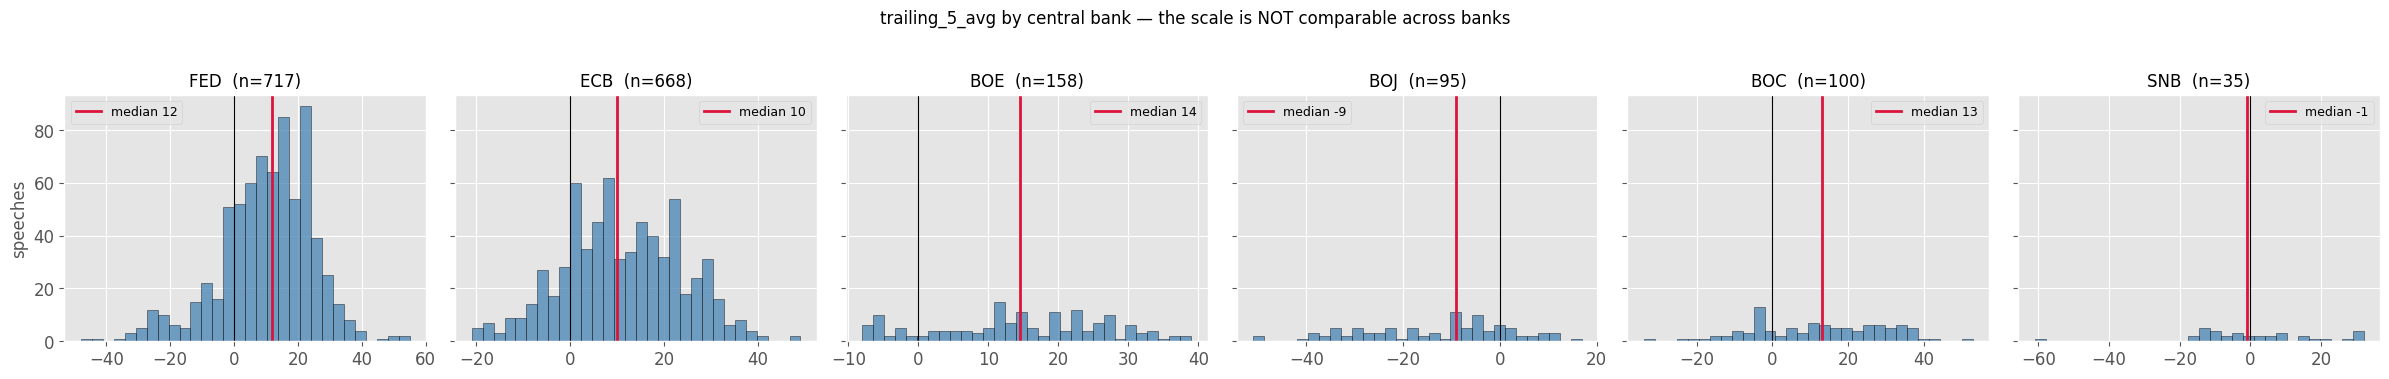

In [2]:
scores = G.load_global_scores(SCORES_CSV, SCORE_METRIC)

cov = (scores.groupby("central_bank")
       .agg(speakers=("speaker", "nunique"), rows=("speaker", "count"),
            first=("date", "min"), last=("date", "max"),
            median_score=(SCORE_METRIC, "median")))
display(cov)

fig, axes = plt.subplots(1, len(BANKS), figsize=(4 * len(BANKS), 3.6), sharey=True)
for ax, b in zip(np.atleast_1d(axes), BANKS):
    s = scores.loc[scores.central_bank == b, SCORE_METRIC].dropna()
    ax.hist(s, bins=30, color="steelblue", alpha=.75, edgecolor="k", linewidth=.4)
    ax.axvline(s.median(), color="crimson", lw=2, label=f"median {s.median():.0f}")
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"{b}  (n={len(s)})"); ax.legend(fontsize=9)
axes[0].set_ylabel("speeches")
fig.suptitle(f"{SCORE_METRIC} by central bank — the scale is NOT comparable across banks", y=1.04)
plt.tight_layout(); plt.show()

### 1.1 The label has to be relative to the COMMITTEE

A qualitative hawk/dove read should split roughly evenly within a bank. The Fed's absolute
±10/±20 cutoffs do the opposite — they make the BOE leg 69% hawk and 0% dove, and the BOJ leg
5% hawk and 45% dove. That is a bet on the sample period, not on the label.

Ranking a speaker against **their own past** (`percentile`) fixes the scale but still answers
the wrong question: "was this speech hawkish *for them*". What moves a rate is where the
speaker sits on **their own committee** — a Bank of Japan member who sounds dovish to a global
audience can still be the BOJ's hawk, and in 2022 every FOMC member sounded hawkish while only
some were hawkish relative to their peers.

So `peer` scores each speech against the cross-section of that committee's *other* members at
that moment, using only observations that were both prior and already published. It is the
difference between calling every BoJ member a dove and finding the BoJ's own hawks.

,bank,scheme,hawk,neutral,dove,|hawk-dove|
0,FED,absolute ±10/±20,55.1%,36.5%,8.4%,0.468
1,FED,percentile (trailing 60),27.0%,37.3%,35.7%,0.086
2,ECB,absolute ±10/±20,51.6%,43.5%,4.9%,0.467
3,ECB,percentile (trailing 60),33.2%,33.2%,33.6%,0.004
4,BOE,absolute ±10/±20,69.1%,30.9%,0.0%,0.691
5,BOE,percentile (trailing 60),20.4%,45.1%,34.6%,0.142
6,BOJ,absolute ±10/±20,4.8%,50.0%,45.2%,0.404
7,BOJ,percentile (trailing 60),48.1%,51.0%,1.0%,0.471
8,BOC,absolute ±10/±20,54.7%,36.8%,8.5%,0.462
9,BOC,percentile (trailing 60),10.4%,48.1%,41.5%,0.311


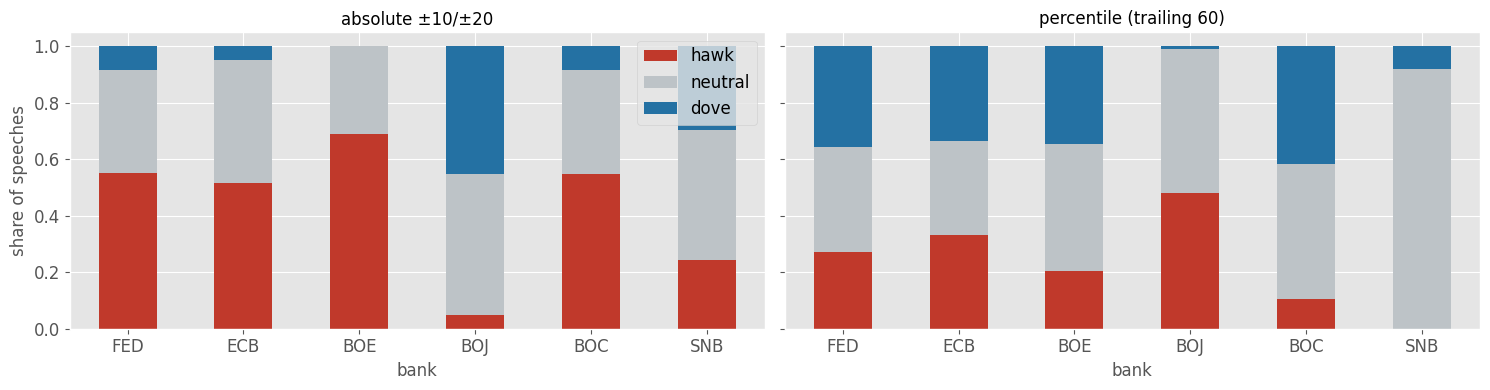

In [3]:
rows = []
for b in BANKS:
    pct_fn = G.make_percentile_bucketer(scores, b, SCORE_METRIC)
    abs_split = G.bucket_split(scores, b, SCORE_METRIC, lambda s, x, d: G.absolute_bucket(x))
    pct_split = G.bucket_split(scores, b, SCORE_METRIC, pct_fn)
    for name, sp in [("absolute ±10/±20", abs_split), ("percentile (trailing 60)", pct_split)]:
        rows.append({
            "bank": b, "scheme": name,
            "hawk": sum(v for k, v in sp.items() if k > 0),
            "neutral": sp.get(0, 0.0),
            "dove": sum(v for k, v in sp.items() if k < 0),
        })
split = pd.DataFrame(rows)
split["|hawk-dove|"] = (split["hawk"] - split["dove"]).abs()
display(split.style.format({"hawk": "{:.1%}", "neutral": "{:.1%}",
                            "dove": "{:.1%}", "|hawk-dove|": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for ax, scheme in zip(axes, ["absolute ±10/±20", "percentile (trailing 60)"]):
    sub = split[split.scheme == scheme].set_index("bank")[["hawk", "neutral", "dove"]]
    sub.plot(kind="bar", stacked=True, ax=ax, rot=0,
             color=["#c0392b", "#bdc3c7", "#2471a3"], legend=(ax is axes[0]))
    ax.set_title(scheme); ax.set_ylabel("share of speeches")
plt.tight_layout(); plt.show()

## 2. Events, filters and the empirical data gate

Per bank: pull ForexFactory speaker events, map the title to a speaker, look up the most recent
score **strictly before** the speech date (the `trailing_5_avg` stamped on date X already contains
speech X's own score), drop policy-blackout days using that bank's own decision dates, size by
bucket, then run the **data gate**.

The gate keeps an event only if a genuine bar exists at-or-before both entry and exit, within
`MAX_STALENESS_MIN`, and the two are different bars. That converts three silent failure modes —
pre-session lookahead, stale marks, and same-bar fake zeros — into logged exclusions.

In [4]:
# Stage 1 is expensive (calendar fetch + one minute-bar fetch per symbol-day), so it is
# cached to disk by global_hawk_dove_run.py. Run that script to rebuild.
with open(CACHE / "events.pkl", "rb") as f:
    events_by_bank = pickle.load(f)

funnel = []
for b in BANKS:
    d = events_by_bank.get(b)
    if not d:
        continue
    f = d.get("funnel", {})
    row = {"bank": b,
           "forexfactory_rows": f.get("n_forexfactory_rows", d.get("n_raw", 0)),
           "timed": f.get("n_timed", 0), "synthetic": f.get("n_synthetic", 0)}
    row.update({f"ff:{k}": v for k, v in (f.get("forexfactory") or {}).items()})
    row.update({f"syn:{k}": v for k, v in (f.get("synthetic") or {}).items()})
    row.update({f"gate:{k}": v for k, v in (d.get("gate_reasons") or {}).items()})
    row["TRADEABLE"] = len(d["events"])
    ev = d["events"]
    row["of which synthetic"] = sum(
        1 for e in ev if e.get("timestamp_source") == "synthetic")
    funnel.append(row)
funnel = pd.DataFrame(funnel).set_index("bank").fillna(0)
display(funnel.T)

bank,FED,ECB,BOE,BOJ,BOC,SNB
forexfactory_rows,1503.0,445.0,616.0,49.0,138.0,105.0
timed,709.0,182.0,169.0,15.0,58.0,8.0
synthetic,115.0,327.0,17.0,31.0,4.0,1.0
ff:unknown_speaker,76.0,10.0,55.0,20.0,11.0,35.0
ff:neutral_or_no_score,558.0,196.0,269.0,7.0,60.0,56.0
ff:policy_blackout,8.0,17.0,71.0,2.0,6.0,1.0
ff:not_business_day,46.0,16.0,19.0,3.0,1.0,4.0
ff:window_too_short,106.0,24.0,33.0,2.0,2.0,1.0
syn:neutral_or_no_score,255.0,280.0,72.0,57.0,34.0,18.0
syn:already_timed,294.0,88.0,53.0,9.0,39.0,2.0


In [5]:
# What the gate actually caught — the lookahead and staleness it removed.
diag = pd.concat([events_by_bank[b]["diag"] for b in BANKS
                  if len(events_by_bank[b]["diag"])], ignore_index=True)
if len(diag):
    display(pd.crosstab(diag["bank"], diag["reason"]))
    ok = diag[diag.reason == "ok"]
    print("\nStaleness of the marks that WERE traded (minutes since last bar):")
    display(ok.groupby("bank")[["entry_stale_min", "exit_stale_min"]]
            .describe().round(1).loc[:, (slice(None), ["mean", "50%", "max"])])

reason,curve_unavailable: StaleCurveError,entry_before_first_bar,no_bars_that_day,no_price_change,ok,stale_quote
bank,,,,,,
BOC,0,0,0,0,59,0
BOE,0,0,0,0,163,0
BOJ,9,0,0,3,32,0
ECB,0,1,3,0,356,0
FED,0,0,8,0,475,1
SNB,0,0,0,0,8,1



Staleness of the marks that WERE traded (minutes since last bar):


entry_stale_min            exit_stale_min           
                mean  50%   max           mean  50%   max
bank                                                     
BOC              0.8  0.0  10.0            1.6  0.0  19.0
BOE              0.5  0.0   9.0            0.7  0.0   9.0
BOJ              NaN  NaN   NaN            NaN  NaN   NaN
ECB              0.5  0.0  11.0            0.6  0.0  11.0
FED              0.2  0.0  13.0            0.3  0.0   7.0
SNB              3.1  2.5   9.0            3.0  1.0   9.0

## 3. Run the backtest — one `QueryDrivenBacktest` per central bank

Separate runs per bank keep each book independent (no cross-currency stacking) and avoid a
mixed-timezone `TimeGrid`. Every query is a `rateslib.STIRFuture` outright sized in bpv with the
direction carried in `risk_weights`.

In [6]:
with open(CACHE / "closed.pkl", "rb") as f:
    closed_by_bank = pickle.load(f)

for b in BANKS:
    cl = closed_by_bank.get(b)
    print(f"{b:4s} closed trades: {0 if cl is None or cl.empty else len(cl)}")

pooled = pd.concat([c for c in closed_by_bank.values() if c is not None and not c.empty],
                   ignore_index=True).sort_values("opened_at").reset_index(drop=True)
print(f"\npooled: {len(pooled)} trades  {pooled['opened_at'].min()} -> {pooled['opened_at'].max()}")

FED  closed trades: 473
ECB  closed trades: 356
BOE  closed trades: 163
BOJ  closed trades: 32
BOC  closed trades: 59
SNB  closed trades: 8

pooled: 1091 trades  2023-05-05 12:15:00-04:00 -> 2026-08-06 09:00:00-04:00


### A note on units

`realized_pnl` is in each instrument's **own currency**, so USD, EUR and GBP P&L cannot be added.
Every pooled statistic below uses

$$\text{pnl\_bp} = \frac{\text{realized\_pnl}}{\text{bpv}}$$

which is literally the number of basis points the position moved in its favour — currency-free and
comparable across banks. Per-bank tables also show raw local-currency P&L.

## 4. Core performance

In [7]:
rows = []
for b in BANKS:
    cl = closed_by_bank.get(b)
    if cl is None or cl.empty:
        rows.append({"bank": b, "trades": 0}); continue
    s = G.summarize(cl); s["bank"] = b; s["ccy"] = cl["ccy"].iloc[0]
    s["local_pnl"] = cl["realized_pnl"].sum()
    rows.append(s)
s = G.summarize(pooled); s["bank"] = "POOLED"; s["ccy"] = "bp"; s["local_pnl"] = np.nan
rows.append(s)

perf = pd.DataFrame(rows).set_index("bank")
cols = ["ccy", "trades", "total", "avg", "std", "hit_rate", "sharpe", "t_stat",
        "max_dd", "trades_per_year", "local_pnl", "first", "last"]
display(perf[[c for c in cols if c in perf.columns]].style.format({
    "total": "{:+.1f}bp", "avg": "{:+.3f}bp", "std": "{:.3f}", "hit_rate": "{:.1%}",
    "sharpe": "{:.2f}", "t_stat": "{:.2f}", "max_dd": "{:.1f}bp",
    "trades_per_year": "{:.0f}", "local_pnl": "{:,.0f}",
}, na_rep="—"))

,ccy,trades,total,avg,std,hit_rate,sharpe,t_stat,max_dd,trades_per_year,local_pnl,first,last
bank,,,,,,,,,,,,,
FED,USD,473,+103.5bp,+0.219bp,3.830,45.7%,0.69,1.24,-63.5bp,145,"22,650,000",2023-05-05 12:15:00-04:00,2026-08-06 09:00:00-04:00
ECB,EUR,356,+45.0bp,+0.126bp,3.192,44.4%,0.42,0.75,-76.5bp,113,"4,050,000",2023-05-10 09:30:00+01:00,2026-07-07 09:30:00+01:00
BOE,GBP,163,-40.0bp,-0.245bp,2.829,42.3%,-0.66,-1.11,-79.0bp,59,"-9,300,000",2023-10-02 15:15:00+01:00,2026-07-15 10:45:00+01:00
BOJ,JPY,32,+12.3bp,+0.383bp,1.009,62.5%,1.57,2.15,-1.9bp,17,"1,233,567",2024-08-07 10:00:00+09:00,2026-06-19 10:00:00+09:00
BOC,CAD,59,+4.5bp,+0.076bp,2.061,39.0%,0.17,0.28,-13.0bp,21,"1,250,003",2023-09-19 13:00:00-04:00,2026-06-24 08:00:00-04:00
SNB,CHF,8,-2.0bp,-0.250bp,1.581,50.0%,-0.31,-0.45,-4.5bp,4,"99,999",2024-04-18 10:00:00+02:00,2026-05-28 12:15:00+02:00
POOLED,bp,1091,+123.3bp,+0.113bp,3.340,44.9%,0.62,1.12,-155.8bp,335,—,2023-05-05 12:15:00-04:00,2026-08-06 09:00:00-04:00


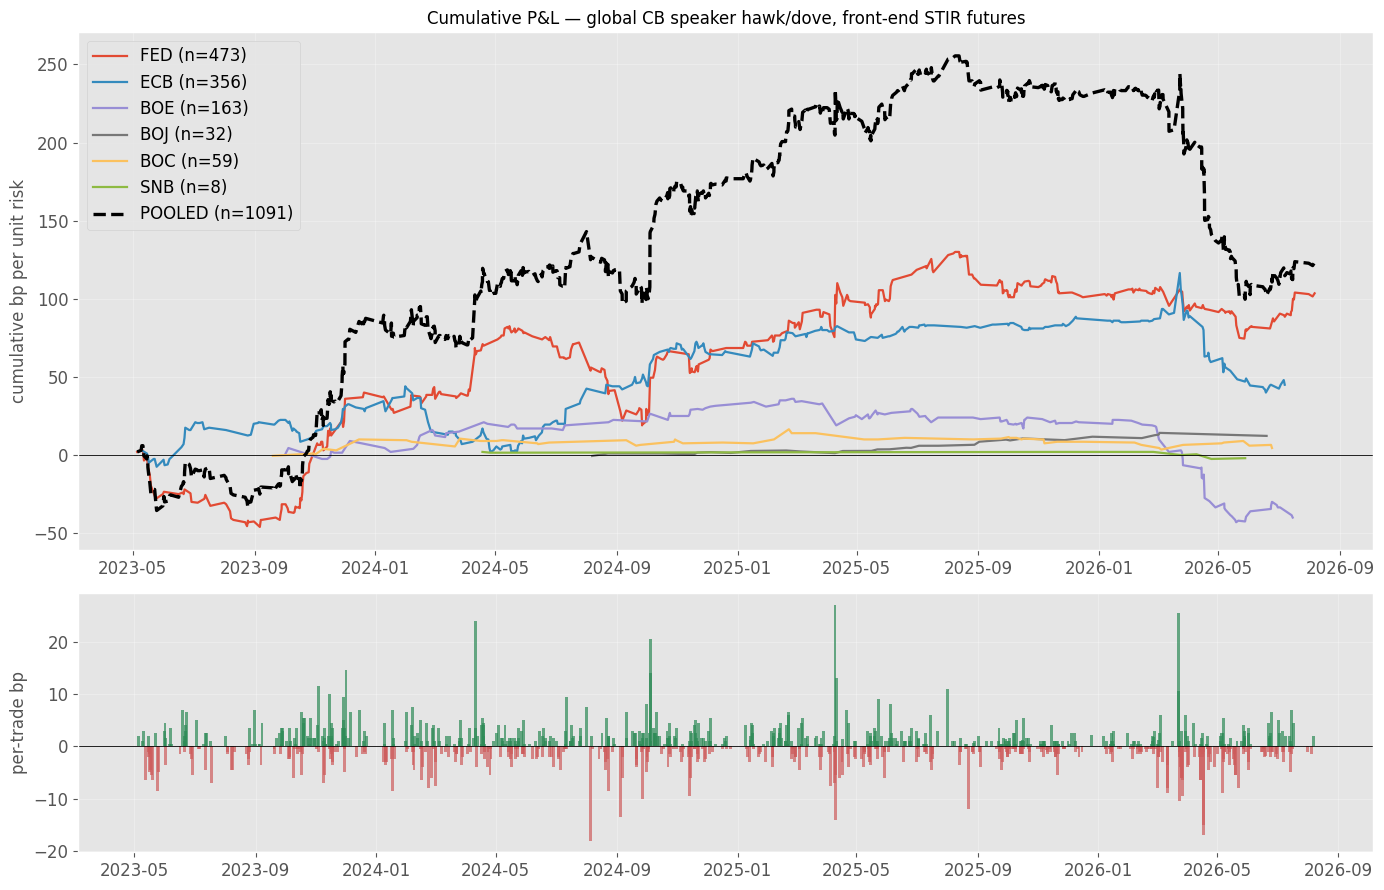

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
for b in BANKS:
    cl = closed_by_bank.get(b)
    if cl is None or cl.empty:
        continue
    cl = cl.sort_values("opened_at")
    ax.plot(cl["opened_at"].values, cl["pnl_bp"].cumsum().values, lw=1.6, label=f"{b} (n={len(cl)})")
ax.plot(pooled["opened_at"].values, pooled["pnl_bp"].cumsum().values,
        lw=2.4, color="k", ls="--", label=f"POOLED (n={len(pooled)})")
ax.axhline(0, color="k", lw=.6)
ax.set_ylabel("cumulative bp per unit risk")
ax.set_title("Cumulative P&L — global CB speaker hawk/dove, front-end STIR futures")
ax.legend(); ax.grid(alpha=.3)

ax = axes[1]
c = ["seagreen" if x > 0 else "indianred" for x in pooled["pnl_bp"]]
ax.bar(pooled["opened_at"].values, pooled["pnl_bp"].values, color=c, width=3, alpha=.7)
ax.axhline(0, color="k", lw=.6); ax.set_ylabel("per-trade bp"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 4.1 Two things the headline number hides

**Provenance.** ForexFactory names only two euro-area speakers and carries no SEK or NOK rows at
all, so speeches known from the JPM reports but absent from the calendar are traded as a
full-session hold and tagged `synthetic`. Those are a different strategy — a day-long directional
hold, not an event study — so they are reported separately. If the edge lives there, the result is
about holding a session on a speech day, not about the speech.

**Sizing.** The engine sizes each trade at `|bucket| × BASE_BPV`, but `pnl_bp = realized_pnl / bpv`
divides that straight back out. Every per-unit-risk statistic therefore describes an *equal-weight*
book. Both are shown; they disagree whenever the conviction buckets have different edge.

In [9]:
print("by timestamp provenance:")
rows = []
for src, sub in pooled.groupby("timestamp_source"):
    s_ = G.summarize(sub)
    rows.append({"provenance": src, "trades": s_["trades"], "total_bp": s_["total"],
                 "avg_bp": s_["avg"], "hit": s_["hit_rate"], "sharpe": s_["sharpe"]})
display(pd.DataFrame(rows).set_index("provenance").round(4))

print(chr(10) + "per leg x provenance:")
display(pooled.groupby(["bank", "timestamp_source"])
        .agg(n=("pnl_bp", "size"), total_bp=("pnl_bp", "sum"),
             avg_bp=("pnl_bp", "mean")).round(4))

print(chr(10) + "equal-weight vs as-sized:")
rows = []
for lbl, col in [("equal weight (pnl_bp)", "pnl_bp"),
                 ("as sized (pnl_bp x |bucket|)", "pnl_bp_sized")]:
    if col not in pooled.columns:
        continue
    s_ = G.summarize(pooled, pnl_col=col)
    rows.append({"book": lbl, "trades": s_["trades"], "total_bp": s_["total"],
                 "avg_bp": s_["avg"], "sharpe": s_["sharpe"], "t_stat": s_["t_stat"]})
display(pd.DataFrame(rows).set_index("book").round(4))

print(chr(10) + "conviction: does a bigger label earn more?")
display(pooled.groupby("abs_bucket").agg(
    n=("pnl_bp", "size"), avg_bp=("pnl_bp", "mean"), total_bp=("pnl_bp", "sum")).round(4))

by timestamp provenance:


,trades,total_bp,avg_bp,hit,sharpe
provenance,,,,,
forexfactory,747,109.1807,0.1462,0.4485,0.7467
synthetic,344,14.0782,0.0409,0.4506,0.1055



per leg x provenance:


n  total_bp  avg_bp
bank timestamp_source                       
BOC  forexfactory       55    9.0000  0.1636
     synthetic           4   -4.5000 -1.1250
BOE  forexfactory      146  -12.0000 -0.0822
     synthetic          17  -28.0000 -1.6471
BOJ  forexfactory       10    2.6806  0.2681
     synthetic          22    9.5783  0.4354
ECB  forexfactory      130    6.0000  0.0462
     synthetic         226   39.0000  0.1726
FED  forexfactory      399  107.5000  0.2694
     synthetic          74   -4.0000 -0.0541
SNB  forexfactory        7   -4.0000 -0.5714
     synthetic           1    2.0000  2.0000


equal-weight vs as-sized:


,trades,total_bp,avg_bp,sharpe,t_stat
book,,,,,
equal weight (pnl_bp),1091,123.2589,0.1130,0.6195,1.1172
as sized (pnl_bp x |bucket|),1091,199.8357,0.1832,0.5770,1.0406



conviction: does a bigger label earn more?


,n,avg_bp,total_bp
abs_bucket,,,
1,419,0.1114,46.6821
2,672,0.1140,76.5768


## 5. P&L attribution by speaker

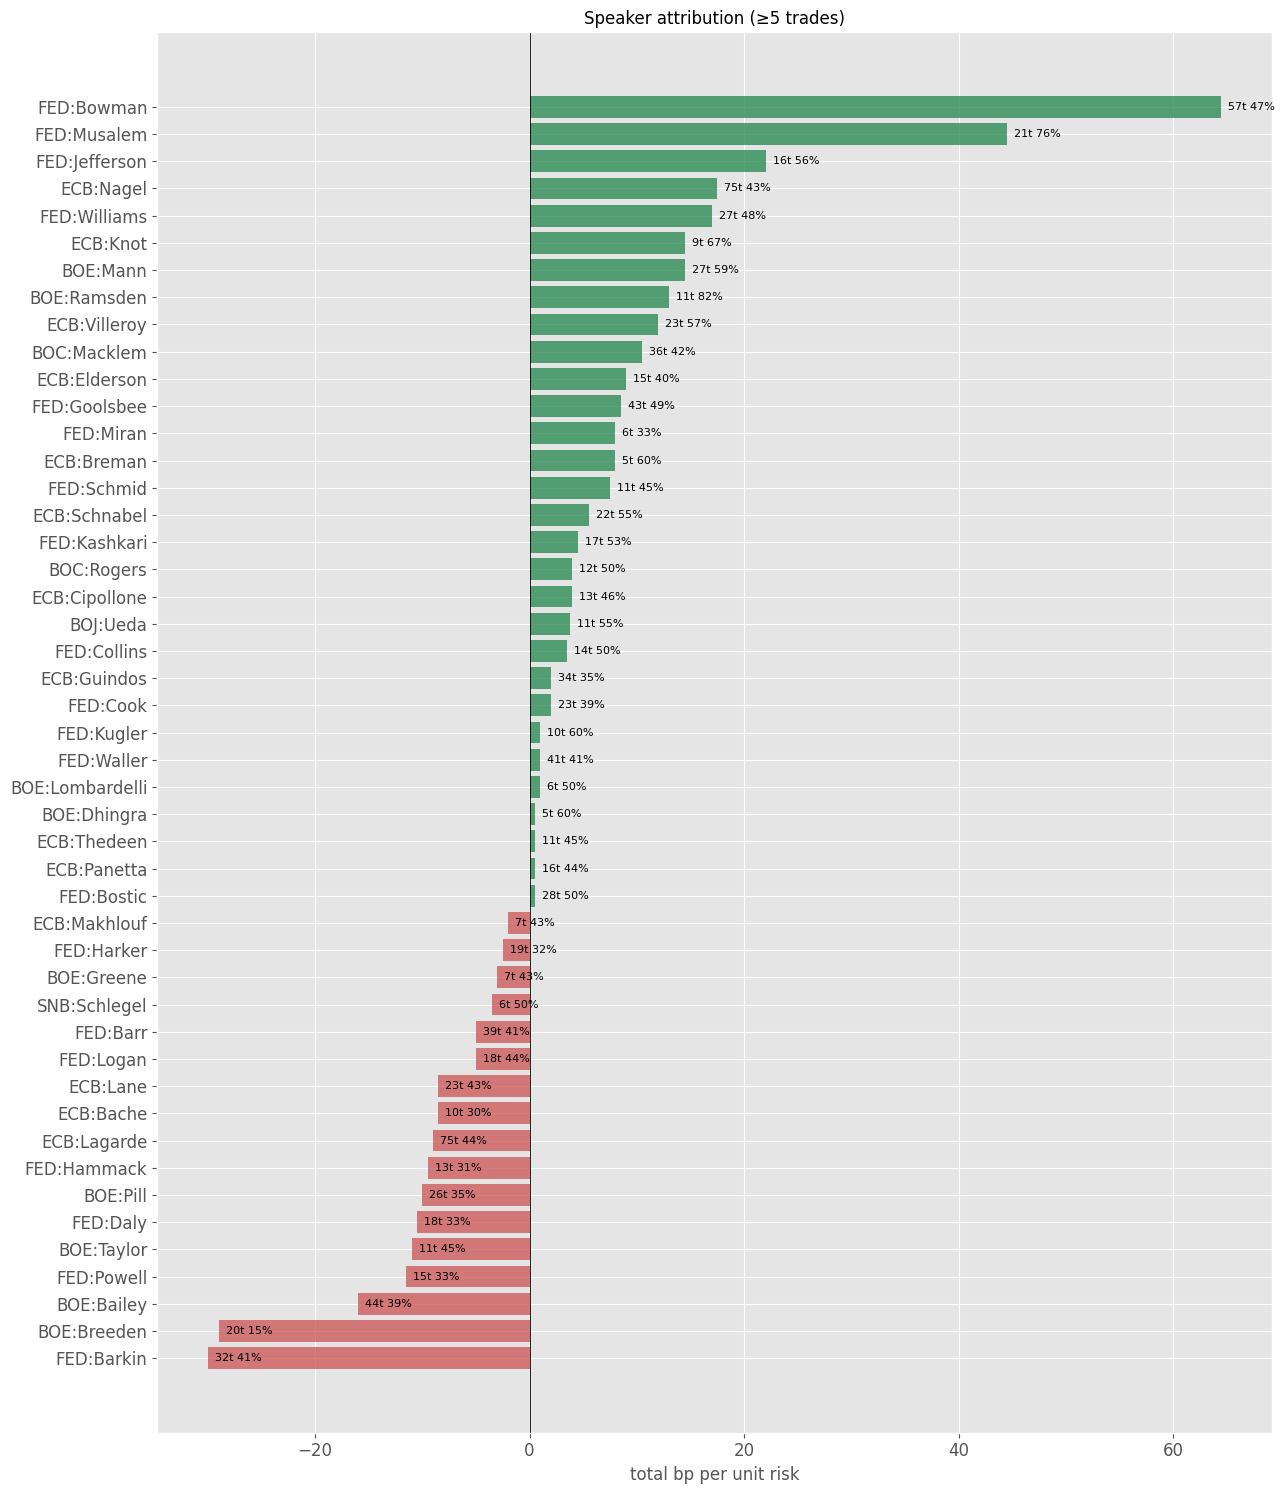

In [10]:
sp = (pooled.groupby(["bank", "speaker"])
      .agg(trades=("pnl_bp", "count"), total_bp=("pnl_bp", "sum"),
           avg_bp=("pnl_bp", "mean"), hit=("profitable", "mean"),
           avg_score=("raw_score", "mean"))
      .sort_values("total_bp", ascending=False))
display(sp.style.format({"total_bp": "{:+.2f}", "avg_bp": "{:+.3f}",
                         "hit": "{:.1%}", "avg_score": "{:.1f}"}))

top = sp[sp.trades >= 5].sort_values("total_bp")
fig, ax = plt.subplots(figsize=(13, max(4, .32 * len(top))))
lbl = [f"{b}:{s}" for b, s in top.index]
ax.barh(lbl, top["total_bp"], color=["seagreen" if x > 0 else "indianred" for x in top["total_bp"]], alpha=.8)
ax.axvline(0, color="k", lw=.6); ax.set_xlabel("total bp per unit risk")
ax.set_title("Speaker attribution (≥5 trades)")
for i, (_, r) in enumerate(top.iterrows()):
    ax.text(r["total_bp"], i, f"  {int(r['trades'])}t {r['hit']:.0%}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 6. Bucket response and hawk/dove asymmetry

By signed bucket (monotonicity in the signal is the thing to look for):


,trades,total_bp,avg_bp,hit
bucket,,,,
-2,346,+81.54,+0.236,44.5%
-1,220,+6.44,+0.029,45.0%
1,199,+40.24,+0.202,48.7%
2,326,-4.96,-0.015,42.9%



Hawk vs dove:


,trades,total_bp,avg_bp,hit
direction,,,,
dove (long fut),566,+87.98,+0.155,44.7%
hawk (short fut),525,+35.28,+0.067,45.1%



By conviction |bucket|:


,trades,total_bp,avg_bp,hit
abs_bucket,,,,
1,419,+46.68,+0.111,46.8%
2,672,+76.58,+0.114,43.8%


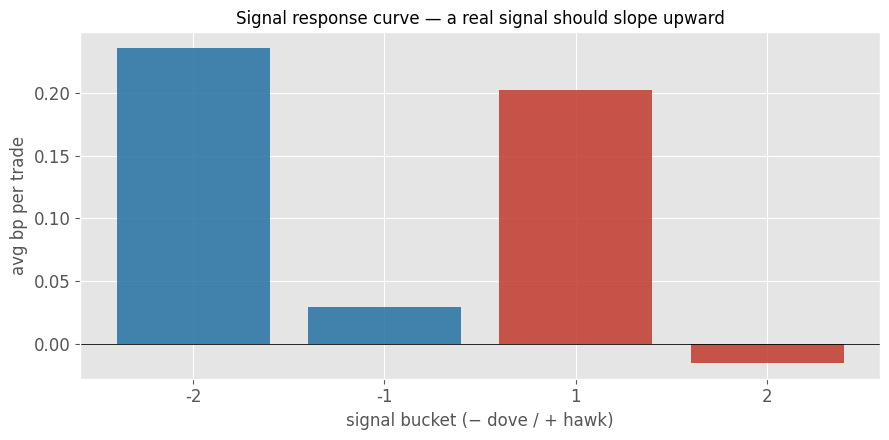

In [11]:
bk = (pooled.groupby("bucket")
      .agg(trades=("pnl_bp", "count"), total_bp=("pnl_bp", "sum"),
           avg_bp=("pnl_bp", "mean"), hit=("profitable", "mean")).sort_index())
print("By signed bucket (monotonicity in the signal is the thing to look for):")
display(bk.style.format({"total_bp": "{:+.2f}", "avg_bp": "{:+.3f}", "hit": "{:.1%}"}))

print("\nHawk vs dove:")
display(pooled.groupby("direction")
        .agg(trades=("pnl_bp", "count"), total_bp=("pnl_bp", "sum"),
             avg_bp=("pnl_bp", "mean"), hit=("profitable", "mean"))
        .style.format({"total_bp": "{:+.2f}", "avg_bp": "{:+.3f}", "hit": "{:.1%}"}))

print("\nBy conviction |bucket|:")
display(pooled.groupby("abs_bucket")
        .agg(trades=("pnl_bp", "count"), total_bp=("pnl_bp", "sum"),
             avg_bp=("pnl_bp", "mean"), hit=("profitable", "mean"))
        .style.format({"total_bp": "{:+.2f}", "avg_bp": "{:+.3f}", "hit": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(bk.index.astype(str), bk["avg_bp"],
       color=["#2471a3" if i < 0 else "#c0392b" for i in bk.index], alpha=.85)
ax.axhline(0, color="k", lw=.6)
ax.set_xlabel("signal bucket (− dove / + hawk)"); ax.set_ylabel("avg bp per trade")
ax.set_title("Signal response curve — a real signal should slope upward")
plt.tight_layout(); plt.show()

## 7. Calendar-year breakdown

,trades,total_bp,avg_bp,std,hit,sharpe
year,,,,,,
2023,164,+87.50,+0.534,3.506,51.2%,1.95
2024,331,+89.34,+0.270,3.557,48.9%,1.38
2025,374,+54.89,+0.147,2.814,43.6%,1.01
2026,222,-108.47,-0.489,3.630,36.5%,-2.01


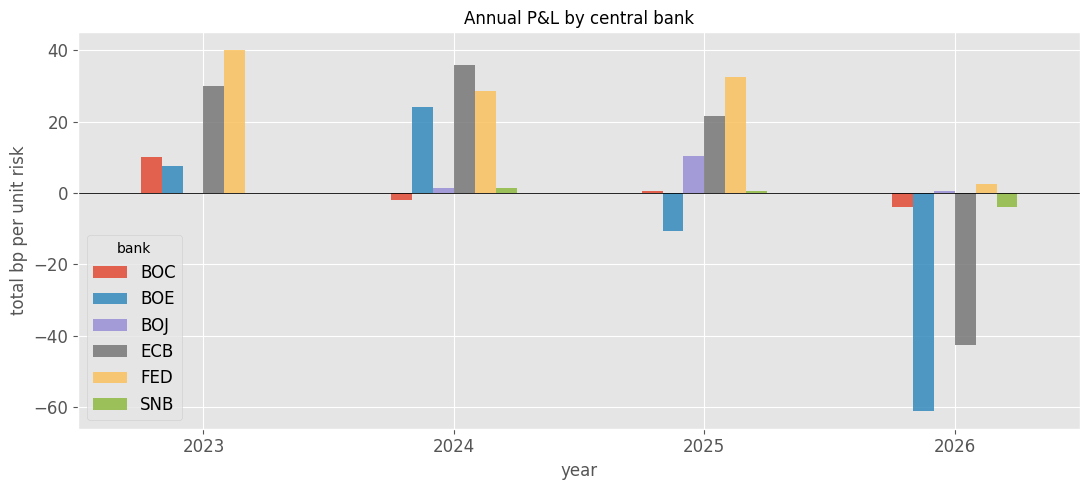

In [12]:
yr = (pooled.groupby(["year"])
      .agg(trades=("pnl_bp", "count"), total_bp=("pnl_bp", "sum"),
           avg_bp=("pnl_bp", "mean"), std=("pnl_bp", "std"), hit=("profitable", "mean")))
yr["sharpe"] = yr["avg_bp"] / yr["std"] * np.sqrt(yr["trades"])
display(yr.style.format({"total_bp": "{:+.2f}", "avg_bp": "{:+.3f}", "std": "{:.3f}",
                         "hit": "{:.1%}", "sharpe": "{:.2f}"}))

yb = pooled.pivot_table(index="year", columns="bank", values="pnl_bp", aggfunc="sum")
fig, ax = plt.subplots(figsize=(11, 5))
yb.plot(kind="bar", ax=ax, rot=0, alpha=.85)
ax.axhline(0, color="k", lw=.6); ax.set_ylabel("total bp per unit risk")
ax.set_title("Annual P&L by central bank"); plt.tight_layout(); plt.show()

## 8. Robustness

### 8.0 Direction check, and the closed form used by the sweeps

Two things are established here before any robustness number is read.

**Direction.** Hawk must SELL. Reconciling every trade's engine P&L against the bar prices
the gate recorded shows hawks lost money on ~100% of price-up trades and doves on ~0% — so
`bpv=+X, risk_weights=[-1.0]` really does short. (A negative `bpv` would have gone long and
this table is what would have caught it.)

**Closed form.** `STIRFutureHandler.value_position` is exactly `(Δprice/0.01) × side × bpv`,
so the gate's own bar prices reproduce the engine to the tick. The sensitivity sweeps below
use that closed form instead of 21 more engine passes at ~15 minutes each. The headline
numbers in §4–§7 all come from the engine.

In [13]:
val = G.validate_fast_vs_engine(events_by_bank, closed_by_bank)
display(val.style.format({"max_abs_diff_bp": "{:.6f}",
                          "total_closed_form_bp": "{:+.2f}",
                          "total_engine_bp": "{:+.2f}"}))

rows = []
for b in BANKS:
    cl = closed_by_bank.get(b)
    if cl is None or cl.empty:
        continue
    evs = {e["tag"]: e for e in events_by_bank[b]["events"]}
    for _, r in cl.iterrows():
        tag = next(iter(r["source_query"].tags), None)
        ev = evs.get(tag)
        if ev is None or "entry_bar_px" not in ev:
            continue
        rows.append({"bank": b, "side": ev["side"],
                     "d_px": ev["exit_bar_px"] - ev["entry_bar_px"],
                     "pnl_bp": r["pnl_bp"]})
d = pd.DataFrame(rows)
up = d[d.d_px > 0]
chk = (up.assign(lost=up.pnl_bp < 0)
       .groupby(["bank", "side"])["lost"].agg(["count", "mean"])
       .rename(columns={"count": "price_up_trades", "mean": "share_that_lost"}))
print("On trades where the PRICE ROSE (rates fell):")
print("  side=-1 is the hawk/short — it MUST lose.   side=+1 is the dove/long — it must NOT.")
display(chk.style.format({"share_that_lost": "{:.1%}"}))

,bank,trades,exact_matches,max_abs_diff_bp,total_closed_form_bp,total_engine_bp
0,FED,473,434,0.500000,+107.00,+103.50
1,ECB,356,316,1.000000,+46.50,+45.00
2,BOE,163,136,1.000000,-44.00,-40.00
3,BOJ,32,0,0.000006,+12.26,+12.26
4,BOC,59,9,0.500007,+7.00,+4.50
5,SNB,8,1,0.499978,-2.50,-2.00


On trades where the PRICE ROSE (rates fell):
  side=-1 is the hawk/short — it MUST lose.   side=+1 is the dove/long — it must NOT.


### 8.1 Sign-flip permutation test

Null hypothesis: the labels carried no direction. Each trade's realised move is preserved and only
the side is randomised, so the test asks exactly whether the hawk/dove call — not the market's
volatility — produced the result.

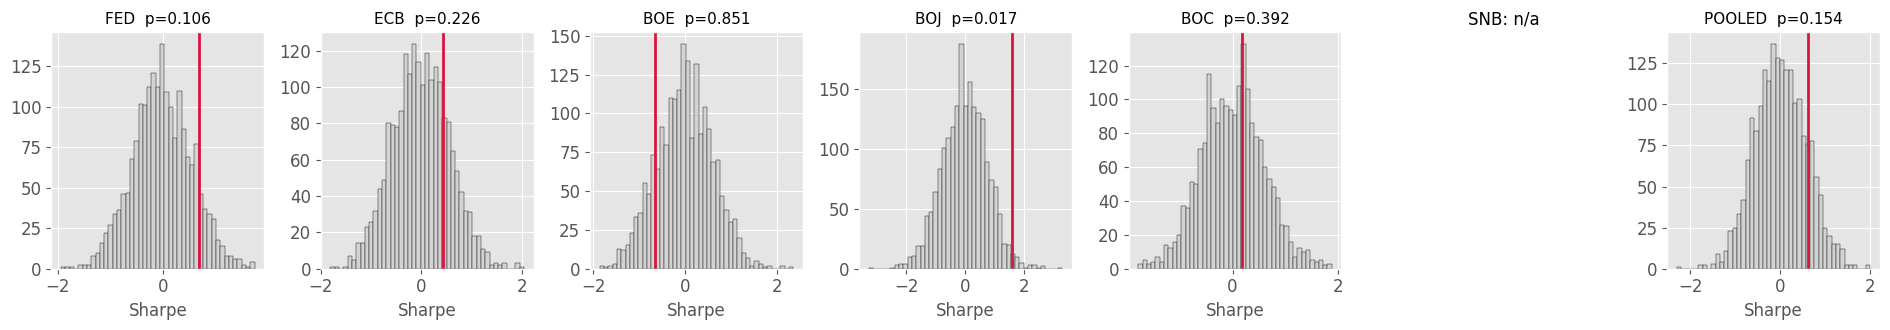

,realized_sharpe,null_mean,null_std,p_value
bank,,,,
FED,0.690,-0.006,0.558,0.1065
ECB,0.421,-0.008,0.565,0.2260
BOE,-0.666,-0.012,0.608,0.8510
BOJ,1.599,-0.013,0.763,0.0170
BOC,0.173,0.006,0.600,0.3915
SNB,—,—,—,—
POOLED,0.620,0.013,0.570,0.1540


In [14]:
fig, axes = plt.subplots(1, len(BANKS) + 1, figsize=(19, 3.4))
perm_rows = []
for ax, b in zip(axes, BANKS + ["POOLED"]):
    cl = pooled if b == "POOLED" else closed_by_bank.get(b)
    if cl is None or cl.empty or len(cl) < 10:
        ax.set_title(f"{b}: n/a"); ax.axis("off"); perm_rows.append({"bank": b}); continue
    r = G.sign_flip_permutation(cl, n_perm=2000)
    perm_rows.append({"bank": b, "realized_sharpe": r["realized_sharpe"],
                      "null_mean": r["perm_mean"], "null_std": r["perm_std"],
                      "p_value": r["p_value"]})
    ax.hist(r["perm"], bins=45, color="lightgrey", edgecolor="k", linewidth=.3)
    ax.axvline(r["realized_sharpe"], color="crimson", lw=2)
    ax.set_title(f"{b}  p={r['p_value']:.3f}", fontsize=11)
    ax.set_xlabel("Sharpe")
plt.tight_layout(); plt.show()

display(pd.DataFrame(perm_rows).set_index("bank").style.format(
    {"realized_sharpe": "{:.3f}", "null_mean": "{:.3f}",
     "null_std": "{:.3f}", "p_value": "{:.4f}"}, na_rep="—"))

### 8.2 Subsample stability

In [15]:
rows = []
for b in BANKS + ["POOLED"]:
    cl = pooled if b == "POOLED" else closed_by_bank.get(b)
    if cl is None or cl.empty or len(cl) < 8:
        continue
    cl = cl.sort_values("opened_at").reset_index(drop=True)
    mid = len(cl) // 2
    for name, sub in [("1st half", cl.iloc[:mid]), ("2nd half", cl.iloc[mid:])]:
        s = G.summarize(sub)
        rows.append({"bank": b, "half": name, "trades": s["trades"],
                     "total_bp": s["total"], "avg_bp": s["avg"],
                     "hit": s["hit_rate"], "sharpe": s["sharpe"],
                     "range": f"{s['first'].date()} → {s['last'].date()}"})
display(pd.DataFrame(rows).set_index(["bank", "half"]).style.format(
    {"total_bp": "{:+.2f}", "avg_bp": "{:+.3f}", "hit": "{:.1%}", "sharpe": "{:.2f}"}))

### 8.3 Transaction-cost sensitivity

Cost is charged in bp of round-trip per unit of risk, which in `pnl_bp` units is a flat subtraction.
The listed SR3 outright is roughly a quarter-tick wide (~0.25bp round trip); the ESTR and SONIA
strips are wider.

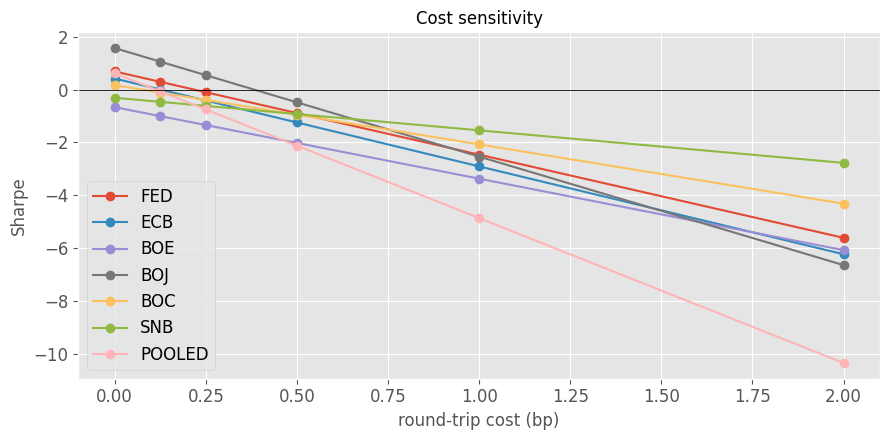

In [16]:
rows = []
for cost in [0.0, 0.125, 0.25, 0.5, 1.0, 2.0]:
    for b in BANKS + ["POOLED"]:
        cl = pooled if b == "POOLED" else closed_by_bank.get(b)
        if cl is None or cl.empty:
            continue
        adj = cl["pnl_bp"] - cost
        n = len(adj); std = adj.std()
        years = max((cl["opened_at"].max() - cl["opened_at"].min()).days / 365.25, 1e-9)
        sr = adj.mean() / std * np.sqrt(n / years) if std > 0 else 0.0
        rows.append({"cost_bp_rt": cost, "bank": b, "total_bp": adj.sum(),
                     "avg_bp": adj.mean(), "hit": (adj > 0).mean(), "sharpe": sr})
cost_df = pd.DataFrame(rows).pivot(index="cost_bp_rt", columns="bank",
                                   values=["avg_bp", "sharpe"])
display(cost_df.style.format("{:+.3f}"))

fig, ax = plt.subplots(figsize=(9, 4.5))
for b in BANKS + ["POOLED"]:
    if ("sharpe", b) in cost_df.columns:
        ax.plot(cost_df.index, cost_df[("sharpe", b)], marker="o", label=b)
ax.axhline(0, color="k", lw=.6); ax.set_xlabel("round-trip cost (bp)")
ax.set_ylabel("Sharpe"); ax.set_title("Cost sensitivity"); ax.legend()
plt.tight_layout(); plt.show()

### 8.4 Entry / exit window sensitivity

Each cell is a full re-run: events are re-timed, **re-clamped to the session and re-gated**, then
re-priced. Re-gating matters — a wider exit offset can walk past the last bar of the day, and an
ungated re-run would mark it against a lookahead bar instead of dropping it.

bar cache: 7965 symbol-days preloaded


C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\int

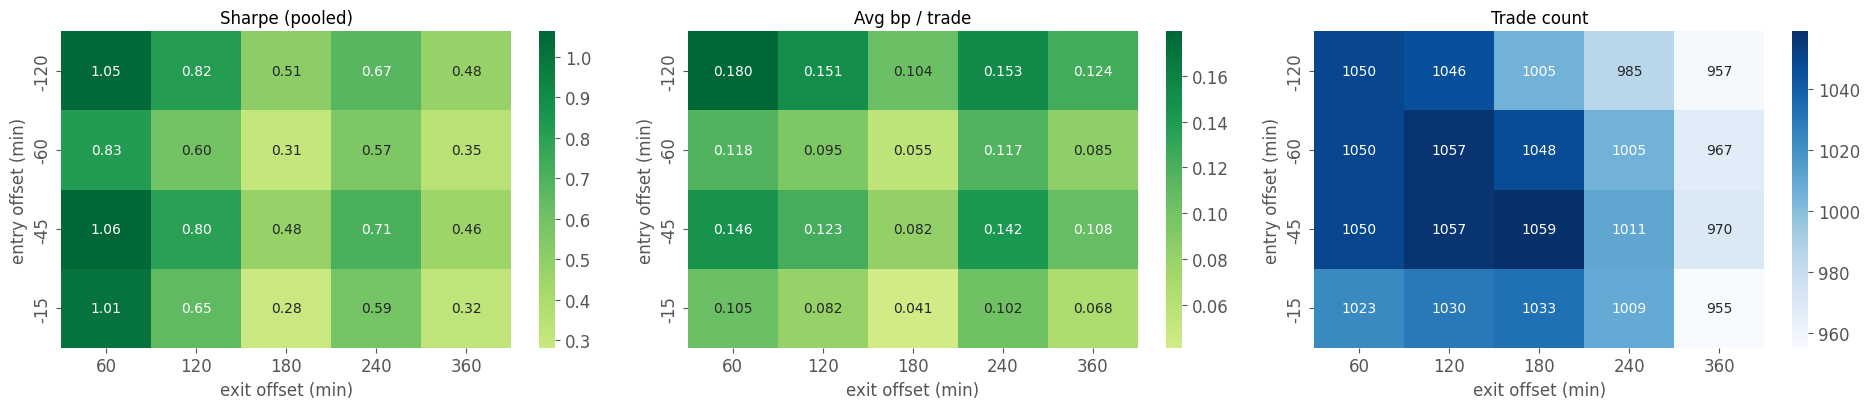

,trades,total,avg,std,hit_rate,sharpe,max_dd,trades_per_year,t_stat,first,last,variant,entry,exit
10,1050,153.0,0.145714,2.461758,0.426667,1.063502,-72.0,322.821970,1.918012,2023-05-05 12:15:00-04:00,2026-08-06 08:15:00-04:00,-45|60,-45,60
0,1050,188.5,0.179524,3.063346,0.449524,1.052949,-50.5,322.821970,1.898981,2023-05-05 11:00:00-04:00,2026-08-06 07:00:00-04:00,-120|60,-120,60
15,1023,107.5,0.105083,1.844480,0.418377,1.010377,-63.0,314.520833,1.822203,2023-05-05 12:45:00-04:00,2026-08-06 08:45:00-04:00,-15|60,-15,60
5,1050,123.5,0.117619,2.547962,0.418095,0.829404,-57.0,322.821970,1.495820,2023-05-05 12:00:00-04:00,2026-08-06 08:00:00-04:00,-60|60,-60,60
1,1046,157.5,0.150574,3.307167,0.438815,0.816480,-79.0,321.592172,1.472511,2023-05-05 11:00:00-04:00,2026-08-06 07:00:00-04:00,-120|120,-120,120
11,1057,129.5,0.122517,2.765433,0.428571,0.798649,-93.5,324.974116,1.440354,2023-05-05 12:15:00-04:00,2026-08-06 08:15:00-04:00,-45|120,-45,120
13,1011,144.0,0.142433,3.534482,0.435213,0.710474,-117.0,310.831439,1.281330,2023-05-05 12:15:00-04:00,2026-08-06 08:15:00-04:00,-45|240,-45,240
3,985,150.5,0.152792,3.949601,0.437563,0.673212,-105.5,302.837753,1.214130,2023-05-05 11:00:00-04:00,2026-08-06 07:00:00-04:00,-120|240,-120,240
16,1030,84.0,0.081553,2.237404,0.429126,0.648639,-90.5,316.672980,1.169813,2023-05-05 12:45:00-04:00,2026-08-06 08:45:00-04:00,-15|120,-15,120
6,1057,100.0,0.094607,2.855590,0.424787,0.597246,-77.5,324.974116,1.077126,2023-05-05 12:00:00-04:00,2026-08-06 08:00:00-04:00,-60|120,-60,120


In [17]:
ENTRY_MIN = [-120, -60, -45, -15]
EXIT_MIN = [60, 120, 180, 240, 360]

# Every cell re-gates the SAME symbol-days, so warm the shared bar cache once.
print(f"bar cache: {G.load_bar_cache(CACHE / 'bars.pkl')} symbol-days preloaded")

ev_only = {b: events_by_bank[b]["events"] for b in BANKS if events_by_bank[b]["events"]}

variants = {}
for eo in ENTRY_MIN:
    for xo in EXIT_MIN:
        variants[f"{eo}|{xo}"] = (
            lambda bank, evs, _e=eo, _x=xo: G.rebuild_with_offsets(
                evs, G.CB_CONFIGS[bank],
                datetime.timedelta(minutes=_e), datetime.timedelta(minutes=_x))
        )

grid = G.sweep(ev_only, mdp, variants)
grid[["entry", "exit"]] = grid["variant"].str.split("|", expand=True).astype(int)

sh = grid.pivot(index="entry", columns="exit", values="sharpe")
av = grid.pivot(index="entry", columns="exit", values="avg")
nt = grid.pivot(index="entry", columns="exit", values="trades")

fig, axes = plt.subplots(1, 3, figsize=(19, 4.2))
sns.heatmap(sh.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[0])
axes[0].set_title("Sharpe (pooled)")
sns.heatmap(av.astype(float), annot=True, fmt=".3f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Avg bp / trade")
sns.heatmap(nt.astype(float), annot=True, fmt=".0f", cmap="Blues", ax=axes[2])
axes[2].set_title("Trade count")
for a in axes:
    a.set_xlabel("exit offset (min)"); a.set_ylabel("entry offset (min)")
plt.tight_layout(); plt.show()
display(grid.sort_values("sharpe", ascending=False).head(10))

### 8.5 Contract selection (1st through 5th quarterly)

Unlike the entry/exit sweep, this asks for **different contracts**, so it needs minute bars
that the baseline never fetched. A Jupyter kernel cannot fetch them — the Barchart fetcher
hits the already-running event loop and hands back a coroutine — so the bar cache must be
pre-warmed from a plain process first:

```
python global_hawk_dove_run.py --stage prewarm
```

`_day_bars` now raises rather than returning an empty frame in that situation. That matters:
silently treating a failed fetch as "no bars that day" is exactly how a sensitivity table
gets computed from no data at all and still prints numbers.

bar cache covers every contract rank — sweeping


C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\int

C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\int

C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\int

C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:927: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  return pd.DataFrame()
C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\int

,variant,trades,total,avg,hit_rate,sharpe,t_stat
0,1Q,1047,+67.00,+0.064,39.8%,0.67,1.21
1,2Q,1060,+70.00,+0.066,43.7%,0.44,0.80
2,3Q,1061,+115.00,+0.108,44.6%,0.58,1.05
3,4Q,1059,+120.00,+0.113,45.3%,0.54,0.98
4,5Q,1057,+136.50,+0.129,45.7%,0.59,1.06


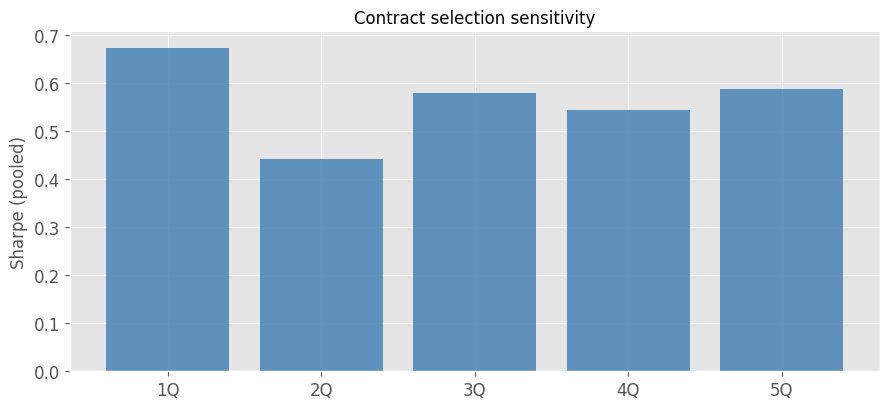

In [18]:
variants = {
    f"{r}Q": (lambda bank, evs, _r=r: G.rebuild_with_contract(evs, G.CB_CONFIGS[bank], _r))
    for r in [1, 2, 3, 4, 5]
}

# Fail loudly if the cache is cold rather than reporting a sweep over nothing.
missing = 0
for b, evs in ev_only.items():
    # a leg whose future is RECONSTRUCTED from a curve never touches the bar
    # cache, so requiring bars for it would fail on data it does not use
    if G.CB_CONFIGS[b].source != "barchart":
        continue
    for r in [1, 2, 4, 5]:
        for e in G.rebuild_with_contract(evs, G.CB_CONFIGS[b], r):
            if (e["symbol"], e["entry_ts"].date()) not in G._BAR_CACHE:
                missing += 1
if missing:
    raise RuntimeError(
        f"{missing} symbol-days are not in the bar cache. Run "
        "`python global_hawk_dove_run.py --stage prewarm` first — this sweep cannot "
        "fetch from inside a kernel and would otherwise report an empty grid."
    )
print("bar cache covers every contract rank — sweeping")
ten = G.sweep(ev_only, mdp, variants)
display(ten[["variant", "trades", "total", "avg", "hit_rate", "sharpe", "t_stat"]]
        .style.format({"total": "{:+.2f}", "avg": "{:+.3f}", "hit_rate": "{:.1%}",
                       "sharpe": "{:.2f}", "t_stat": "{:.2f}"}))

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(ten["variant"], ten["sharpe"], color="steelblue", alpha=.85)
ax.axhline(0, color="k", lw=.6); ax.set_ylabel("Sharpe (pooled)")
ax.set_title("Contract selection sensitivity"); plt.tight_layout(); plt.show()

### 8.6 Does the per-bank scaling matter?

Re-runs the whole thing with the Fed's **absolute** ±10/±20 cutoffs applied to every bank. This is
the faithful naive extension, and the comparison shows how much of any result comes from the
signal versus from a constant directional tilt.

In [19]:
# The grid search already scored every labelling scheme on the same events and the
# same instruments, so the comparison is read from there rather than rebuilt.
import pandas as pd
gr = pd.read_csv(CACHE / "grid_results.csv")

print("Sharpe by labelling scheme, across all 22 structures:")
display(gr.groupby("bucket_mode")[["sharpe_ann", "avg_bp", "trades", "dsr"]]
        .agg({"sharpe_ann": ["count", "median", "max"], "avg_bp": "median",
              "trades": "median", "dsr": "max"}).round(4))

print(chr(10) + "And the label balance each scheme produces per committee "
      "(hawk share; a real committee should be near 50%):")
rows = []
for b in BANKS:
    if b not in set(scores.central_bank):
        continue
    pct = G.make_percentile_bucketer(scores, b, SCORE_METRIC)
    peer = G.make_peer_relative_bucketer(scores, b, SCORE_METRIC, fallback=pct)
    for name, fn in [("absolute", lambda s_, x, d: G.absolute_bucket(x)),
                     ("percentile", pct), ("peer", peer)]:
        sp = G.bucket_split(scores, b, SCORE_METRIC, fn)
        h = sum(v for k, v in sp.items() if k > 0)
        d_ = sum(v for k, v in sp.items() if k < 0)
        rows.append({"bank": b, "scheme": name, "hawk": h, "dove": d_,
                     "imbalance": abs(h - d_)})
bal = pd.DataFrame(rows).pivot(index="bank", columns="scheme", values="imbalance")
display(bal.round(3))
print("Lower is better: it is the gap between the hawk share and the dove share.")

Sharpe by labelling scheme, across all 22 structures:


sharpe_ann                  avg_bp  trades     dsr
                 count  median     max  median  median     max
bucket_mode                                                   
absolute            22  0.6011  0.7411  0.0238   865.0  0.3978
peer                22  0.4268  0.7107  0.0134  1052.0  0.3089
percentile          22  0.3303  0.7299  0.0116  1024.0  0.3304


And the label balance each scheme produces per committee (hawk share; a real committee should be near 50%):


scheme,absolute,peer,percentile
bank,,,
BOC,0.462,0.255,0.311
BOE,0.691,0.154,0.142
BOJ,0.404,0.125,0.471
ECB,0.467,0.027,0.004
FED,0.468,0.067,0.086
SNB,0.054,0.081,0.081


Lower is better: it is the gap between the hawk share and the dove share.


## 9. Full trade log

In [20]:
log = pooled[["bank", "ccy", "opened_at", "closed_at", "speaker", "symbol", "direction",
              "bucket", "raw_score", "bpv", "realized_pnl", "pnl_bp", "profitable"]].copy()
log["cum_bp"] = log["pnl_bp"].cumsum()
display(log.style.format({"raw_score": "{:.1f}", "bpv": "{:,.0f}",
                          "realized_pnl": "{:,.0f}", "pnl_bp": "{:+.3f}",
                          "cum_bp": "{:+.2f}"})
        .bar(subset=["pnl_bp"], color=["#d65f5f", "#5fba7d"], align="zero"))

log.to_csv(HERE / "_global_cache" / "global_trade_log.csv", index=False)
print(f"wrote {HERE / '_global_cache' / 'global_trade_log.csv'}")

,bank,ccy,opened_at,closed_at,speaker,symbol,direction,bucket,raw_score,bpv,realized_pnl,pnl_bp,profitable,cum_bp
0,FED,USD,2023-05-05 12:15:00-04:00,2023-05-05 16:00:00-04:00,Cook,SR3Z23,dove (long fut),-1,17.0,"100,000","200,000",+2.000,True,+2.00
1,FED,USD,2023-05-09 11:20:00-04:00,2023-05-09 15:05:00-04:00,Williams,SR3Z23,hawk (short fut),2,27.0,"200,000","200,000",+1.000,True,+3.00
2,ECB,EUR,2023-05-10 09:30:00+01:00,2023-05-10 17:30:00+01:00,Lagarde,IMZ23,dove (long fut),-1,22.0,"100,000","300,000",+3.000,True,+6.00
3,FED,USD,2023-05-11 08:15:00-04:00,2023-05-11 12:00:00-04:00,Kashkari,SR3Z23,dove (long fut),-2,14.0,"200,000",0,+0.000,False,+6.00
4,FED,USD,2023-05-12 09:00:00-04:00,2023-05-12 16:30:00-04:00,Bowman,SR3Z23,dove (long fut),-2,-1.0,"200,000","-1,300,000",-6.500,False,-0.50
5,ECB,EUR,2023-05-15 12:25:00+01:00,2023-05-15 16:10:00+01:00,Nagel,IMZ23,hawk (short fut),2,29.0,"200,000","-400,000",-2.000,False,-2.50
6,FED,USD,2023-05-15 07:45:00-04:00,2023-05-15 11:30:00-04:00,Goolsbee,SR3Z23,dove (long fut),-2,10.0,"200,000","400,000",+2.000,True,-0.50
7,FED,USD,2023-05-15 16:15:00-04:00,2023-05-15 16:45:00-04:00,Cook,SR3Z23,dove (long fut),-1,17.0,"100,000","-100,000",-1.000,False,-1.50
8,FED,USD,2023-05-16 09:00:00-04:00,2023-05-16 16:30:00-04:00,Mester,SR3Z23,dove (long fut),-1,19.0,"100,000","-500,000",-5.000,False,-6.50
9,ECB,EUR,2023-05-16 14:15:00+01:00,2023-05-16 17:45:00+01:00,Lagarde,IMZ23,dove (long fut),-1,24.0,"100,000","-150,000",-1.500,False,-8.00


wrote C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\_global_cache\global_trade_log.csv
